In [1]:
from cem import CEM
import pandas as pd
import numpy as np
import os
import math
import re
from collections import Counter
import random

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
#from causalml.inference.meta import CausalForest
from causalinference import CausalModel

import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties  # 导入FontProperties
import warnings
import statsmodels.api as sm

warnings.filterwarnings("ignore")

In [2]:
pathau = r'E:\netData\APS\1 Authors\APS_authorsDCCC2.0.zip'

In [3]:
fau = pd.read_csv(pathau)
fau['type'] = fau['type'].map(dict(zip(['获奖学者','非获奖学者'] , ['laureate' , 'non laureate'])))
fau['treatment'] = fau['type'].map(dict(zip(['laureate' , 'non laureate'] , [1 , 0])))

In [4]:
data = fau[['pub_num','h', 'tc','DC','CC', 'dh', 'ch','type']].copy()

In [28]:
d1 = data[data['type'] == 'laureate'].copy()
d2 = data[data['type'] == 'non laureate'].copy()
d1.index = range(len(d1))
d2.index = range(len(d2))

In [97]:
lst = []
for pubn in d1['pub_num'].values:
    while True:
        if pubn in d2['pub_num'].values:
            break
        else:
            pubn -= 1
    x = d2[d2['pub_num']==pubn].sample(n=1).index[0]
    lst.append(x)

In [98]:
d3 = d2.iloc[lst , :].copy()

In [99]:
d3 = d3.copy()

In [100]:
d3['type'] = 'control 1'

In [101]:
dd = pd.concat([d1,d3])

In [102]:
def draw_bar(dd , va ,label, savepath):
    f, ax = plt.subplots(figsize=(7, 7))
    
    sns.set_theme(style="ticks")
    sns.barplot(data=dd, x="type", y=va , errwidth=3, capsize=.2,palette=['#21618C','#D35400'])
    #plt.ylim(0,60)
    
    plt.xticks(size = 30)
    plt.yticks(size = 30)
    plt.xlabel(label,fontsize = 30)
    plt.ylabel('',fontsize = 0)
    plt.savefig("F:/目前研究项目/APS分析/SCIENTOMETRICS SDC SCC/fig/fig 7/{}.pdf".format(savepath),bbox_inches = 'tight')

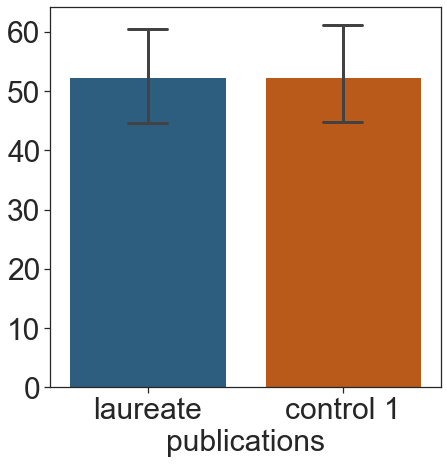

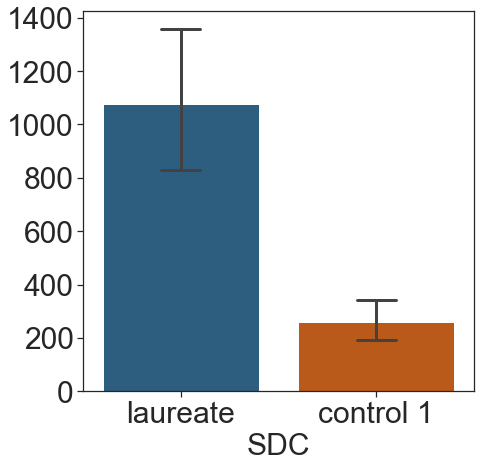

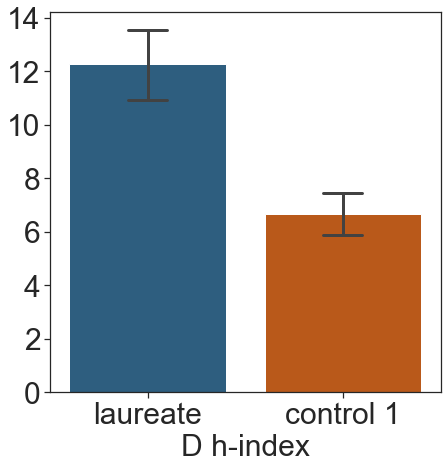

In [103]:
labels = ['publications','SDC','D h-index']
savepath = ['publications1','SDC1','dh1']
valst = [ 'pub_num',  'DC','dh']
for m in range(len(valst)):
    draw_bar(dd ,valst[m], labels[m] , savepath[m])

In [104]:
[scipy.stats.ttest_ind(d1[m].values , d3[m].values,equal_var=False,alternative='two-sided') for m in valst]

[Ttest_indResult(statistic=0.0012788522944935754, pvalue=0.9989806120334662),
 Ttest_indResult(statistic=5.800650786928439, pvalue=3.8747681699727576e-08),
 Ttest_indResult(statistic=7.067137568026514, pvalue=2.4289471153908206e-11)]

In [49]:
# labels = ['publications','h-index','total citations','SDC','SCC','D h-index','C h-index']
# valst = [ 'pub_num', 'h','tc', 'DC', 'CC','dh', 'ch']
# for m in range(len(valst)):
#     draw_bar(dd ,valst[m], labels[m] , valst[m])